**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [1]:
import torch
import numpy as np

In [2]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [3]:
# Перетворення у torch tensors
inputs_t = torch.from_numpy(inputs)
targets_t = torch.from_numpy(targets)

In [4]:
print("Torch inputs:\n", inputs_t)
print("\nTorch targets:\n", targets_t)
print("\nТипи:", type(inputs_t), type(targets_t))

Torch inputs:
 tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

Torch targets:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Типи: <class 'torch.Tensor'> <class 'torch.Tensor'>


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [5]:
torch.random.manual_seed(1)

In [6]:
# Випадкові ваги з нормального розподілу
w = torch.randn(1, 3, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print("w:", w)
print("b:", b)
print("\nФорми:", w.shape, b.shape)

w: tensor([[0.6614, 0.2669, 0.0617]], requires_grad=True)
b: tensor([0.6213], requires_grad=True)

Форми: torch.Size([1, 3]) torch.Size([1])


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [7]:
def model(x, w, b):
    # Лінійна частина: x @ w.T + b
    z = x @ w.t() + b
    
    # Сигмоїда: 1 / (1 + exp(-z))
    y_pred = 1 / (1 + torch.exp(-z))
    
    return y_pred

In [8]:
# Обчислюємо передбачення з поточними w, b
preds = model(inputs_t, w, b)

print("Передбачення моделі:\n", preds)
print("\nФорма:", preds.shape)

Передбачення моделі:
 tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)

Форма: torch.Size([5, 1])


**Спостереження**

Передбачення моделі виглядають підозріло, оскільки всі значення дорівнюють 1.0, незалежно від вхідних даних. 
Така поведінка зазвичай свідчить про те, що модель перебуває у стані насичення сигмоїди. 
Це відбувається тоді, коли лінійна комбінація має дуже великі додатні значення. 

У нашому випадку це зумовлено тим, що:
- вхідні ознаки мають великі масштаби (значення десятків і сотень);
- ваги та зміщення ініціалізовані випадково, без навчання;
- навiть невеликі випадкові коефіцієнти при множенні на великі значення ознак дають дуже великий z;
- сигмоїда при великих z повертає значення, практично рівні 1.0.

Отже, підозрілі передбачення пояснюються тим, що модель ще не навчена, а дані не нормалізовані, що призводить до насичення сигмоїдної функції.

4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [9]:
def binary_cross_entropy(predicted_probs, true_labels):
    # Додаємо epsilon, щоб уникнути log(0)
    eps = 1e-7
    
    # Формула BCE
    loss = - (true_labels * torch.log(predicted_probs + eps) +
              (1 - true_labels) * torch.log(1 - predicted_probs + eps))
    
    # Повертаємо середнє значення втрат
    return torch.mean(loss)

In [10]:
# Обчислюємо втрати для поточних передбачень
loss_value = binary_cross_entropy(preds, targets_t)

print("Binary cross-entropy loss:", loss_value.item())

Binary cross-entropy loss: 6.447237968444824


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [11]:
loss_value.backward()

In [12]:
# Градієнти вагів
print(w)
print(w.grad)

tensor([[0.6614, 0.2669, 0.0617]], requires_grad=True)
tensor([[1.0201e-22, 9.3628e-23, 6.0090e-23]])


In [13]:
# Gradients for bias
print(b)
print(b.grad)

tensor([0.6213], requires_grad=True)
tensor([1.3974e-24])


**Спостереження**

Градієнти параметрів w і b виявилися майже нульовими, оскільки сигмоїдна функція повністю насичена: значення z = x w^T + b є дуже великими, тому сигмоїда повертає значення, близькі до 1.0 для всіх прикладів. У зоні насичення похідна сигмоїди майже дорівнює нулю, що призводить до зникнення градієнтів (vanishing gradients). У результаті, навіть якщо модель робить грубі помилки (наприклад, передбачає 1 замість 0), градієнти залишаються майже нульовими, і параметри не оновлюються. Це зумовлено великими масштабами вхідних ознак та випадковими початковими вагами.

**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [14]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [15]:
preds = model(inputs_t, w, b)
print("Передбачення:\n", preds)

Передбачення:
 tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)


In [16]:
loss = binary_cross_entropy(preds, targets_t)
print("Loss:", loss.item())

Loss: 0.6829455494880676


In [17]:
loss.backward()

print("Градієнти w:\n", w.grad)
print("\nГрадієнти b:\n", b.grad)

Градієнти w:
 tensor([[ -5.4417, -18.9853, -10.0682]])

Градієнти b:
 tensor([-0.0794])


6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [18]:
# 1. Ініціалізація вагів
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# Масштабування, щоб уникнути насичення сигмоїди
w.data = w.data / 1000
b.data = b.data / 1000

learning_rate = 0.001

loss_history = []

for epoch in range(1000):

    # --- 1. Передбачення ---
    preds = model(inputs_t, w, b)

    # --- 2. Втрати ---
    loss = binary_cross_entropy(preds, targets_t)
    loss_history.append(loss.item())

    # --- 3. Градієнти ---
    loss.backward()

    # --- 4. Оновлення ваг ---
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # --- 5. Скидання градієнтів ---
    w.grad.zero_()
    b.grad.zero_()

# --- Фінальні передбачення ---
final_preds = model(inputs_t, w, b)

print("Фінальні передбачення:\n", final_preds)
print("\nОкруглені передбачення:\n", (final_preds > 0.5).float())
print("\nСправжні мітки:\n", targets_t)
print("\nФінальний loss:", loss_history[-1])
print("\nw:", w)
print("b:", b)

Фінальні передбачення:
 tensor([[1.6794e-01],
        [8.7483e-01],
        [9.9771e-01],
        [2.3266e-07],
        [9.9999e-01]], grad_fn=<MulBackward0>)

Округлені передбачення:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Справжні мітки:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Фінальний loss: 0.06402748823165894

w: tensor([[-0.3150,  0.1059,  0.3329]], requires_grad=True)
b: tensor([-0.0138], requires_grad=True)


Вдалось знизити loss від 0.68 до 0.06. Всі передбачення коректні.

**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [19]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [20]:
from torch.utils.data import TensorDataset

# Перетворюємо NumPy → PyTorch тензори
inputs_t = torch.tensor(inputs, dtype=torch.float32)
targets_t = torch.tensor(targets, dtype=torch.float32)

# Створюємо датасет
dataset = TensorDataset(inputs_t, targets_t)

# Виводимо перші 3 елементи
for i in range(3):
    print(f"Елемент {i}:")
    print("  Вхід:", dataset[i][0])
    print("  Мітка:", dataset[i][1])

Елемент 0:
  Вхід: tensor([73., 67., 43.])
  Мітка: tensor([0.])
Елемент 1:
  Вхід: tensor([91., 88., 64.])
  Мітка: tensor([1.])
Елемент 2:
  Вхід: tensor([ 87., 134.,  58.])
  Мітка: tensor([1.])


8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [21]:
from torch.utils.data import DataLoader

# DataLoader з batch_size=5 і перемішуванням
train_dl = DataLoader(dataset, batch_size=5, shuffle=True)

# Виведемо перший батч
first_batch = next(iter(train_dl))

print("Перший батч — входи:")
print(first_batch[0])

print("\nПерший батч — мітки:")
print(first_batch[1])

Перший батч — входи:
tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.],
        [102.,  43.,  37.]])

Перший батч — мітки:
tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [22]:
import torch.nn as nn

class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)   # 3 входи → 1 вихід
        self.sigmoid = nn.Sigmoid()     # сигмоїдна активація

    def forward(self, x):
        out = self.linear(x)            # лінійна комбінація
        out = self.sigmoid(out)         # застосування сигмоїди
        return out

In [23]:
model = LogReg()
model

LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [24]:
opt = torch.optim.SGD(model.parameters(), lr=0.001)

In [25]:
import torch.nn.functional as F

# Визначаємо loss функцію
loss_fn = F.binary_cross_entropy

In [26]:
# Передбачення моделі
preds = model(inputs_t)

# Обчислення втрат
loss = loss_fn(preds, targets_t)

print("Поточні передбачення:\n", preds)
print("\nПоточний loss:", loss.item())

Поточні передбачення:
 tensor([[1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05]], grad_fn=<SigmoidBackward0>)

Поточний loss: 7.631150722503662


Значення loss - 7.63. Це абсолютно нормально на цьому етапі - ми ще не запускали тренування.

- ми тільки створили модель
- ваги випадкові
- оптимізатор ще не робив жодного кроку
- loss великий
- передбачення хаотичні

11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

In [27]:
# Модифікована функцію fit для відстеження втрат
def fit_return_loss(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        # Ініціалізуємо акумулятор для втрат
        total_loss = 0

        for xb, yb in train_dl:
            # Генеруємо передбачення
            pred = model(xb)

            # Обчислюємо втрати
            loss = loss_fn(pred, yb)

            # Виконуємо градієнтний спуск
            loss.backward()
            opt.step()
            opt.zero_grad()

            # Накопичуємо втрати
            total_loss += loss.item()

        # Обчислюємо середні втрати для епохи
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)

        # Виводимо підсумок епохи
        if (epoch + 1) % 10 == 0:
          print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses

In [28]:
losses = fit_return_loss(
    num_epochs=1000,
    model=model,
    loss_fn=loss_fn,
    opt=opt,
    train_dl=train_dl
)

Epoch [10/1000], Loss: 2.1457
Epoch [20/1000], Loss: 0.4342
Epoch [30/1000], Loss: 0.6794
Epoch [40/1000], Loss: 0.3671
Epoch [50/1000], Loss: 0.2716
Epoch [60/1000], Loss: 0.6356
Epoch [70/1000], Loss: 0.3086
Epoch [80/1000], Loss: 0.1488
Epoch [90/1000], Loss: 0.1773
Epoch [100/1000], Loss: 0.1438
Epoch [110/1000], Loss: 0.2307
Epoch [120/1000], Loss: 0.3256
Epoch [130/1000], Loss: 0.1093
Epoch [140/1000], Loss: 0.1172
Epoch [150/1000], Loss: 0.1540
Epoch [160/1000], Loss: 0.0905
Epoch [170/1000], Loss: 0.0970
Epoch [180/1000], Loss: 0.1315
Epoch [190/1000], Loss: 0.2552
Epoch [200/1000], Loss: 0.0788
Epoch [210/1000], Loss: 0.1109
Epoch [220/1000], Loss: 0.0828
Epoch [230/1000], Loss: 0.0906
Epoch [240/1000], Loss: 0.1015
Epoch [250/1000], Loss: 0.0768
Epoch [260/1000], Loss: 0.0701
Epoch [270/1000], Loss: 0.0784
Epoch [280/1000], Loss: 0.0686
Epoch [290/1000], Loss: 0.0673
Epoch [300/1000], Loss: 0.0587
Epoch [310/1000], Loss: 0.0688
Epoch [320/1000], Loss: 0.0555
Epoch [330/1000],

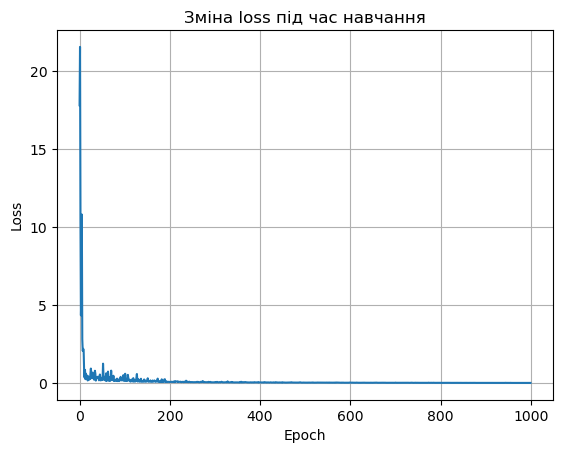

In [29]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Зміна loss під час навчання")
plt.grid(True)
plt.show()

In [30]:
with torch.no_grad():
    final_preds = model(inputs_t)

print("Фінальні передбачення:\n", final_preds)
print("\nОкруглені передбачення:\n", (final_preds > 0.5).float())
print("\nСправжні мітки:\n", targets_t)

Фінальні передбачення:
 tensor([[5.7505e-02],
        [9.6006e-01],
        [9.9962e-01],
        [3.4784e-11],
        [1.0000e+00],
        [5.7505e-02],
        [9.6006e-01],
        [9.9962e-01],
        [3.4784e-11],
        [1.0000e+00],
        [5.7505e-02],
        [9.6006e-01],
        [9.9962e-01],
        [3.4784e-11],
        [1.0000e+00]])

Округлені передбачення:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Справжні мітки:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])


In [31]:
print("Ваги моделі (w):")
print(model.linear.weight.data)

print("\nЗміщення (b):")
print(model.linear.bias.data)

Ваги моделі (w):
tensor([[-0.5028,  0.1340,  0.5815]])

Зміщення (b):
tensor([-0.0788])


**Висновок**

Loss - знизився втричі до 0.02. Передбачення точні.